# 6. Campos de Direções, Equilíbrios e Estabilidade em Dimensão Um

Nesta seção não procuramos **resolver** uma equação diferencial, isto é, encontrar uma expressão para suas curvas integrais. Queremos
agora saber:

> **O que podemos descobrir sobre as soluções sem resolvê-las explicitamente?**

A referência principal desta seção é o Capítulo 2 de Steven H. Strogatz, *Nonlinear Dynamics and Chaos*, especialmente as seções sobre interpretação geométrica, pontos de equilíbrio e análise linear de estabilidade.

Começaremos com a equação geral de primeira ordem

$$
y'=f(x,y),
$$

e depois nos concentraremos nas equações **autônomas**

$$
\boxed{
y'=f(y).
}
$$

N

## 6.1 Relembrando o campo de direções

Para uma EDO

$$
y'=f(x,y),
$$

a equação determina, em cada ponto $(x,y)$, a inclinação

$$
m=f(x,y)
$$

da reta tangente à curva integral que passa por esse ponto.

Uma direção com essa inclinação pode ser representada pelo vetor

$$
(1,f(x,y)).
$$

Normalizando,

$$
\boxed{
\frac{(1,f(x,y))}
{\sqrt{1+f(x,y)^2}}
}
$$

obtemos um vetor de comprimento $1$ com a mesma inclinação.

Visualizamos o conjunto desses pequenos segmentos como **campo de direções** da EDO.

Pergunta: Qual a diferença entre o **campo de direções** e o **campo de vetores** da equação ?

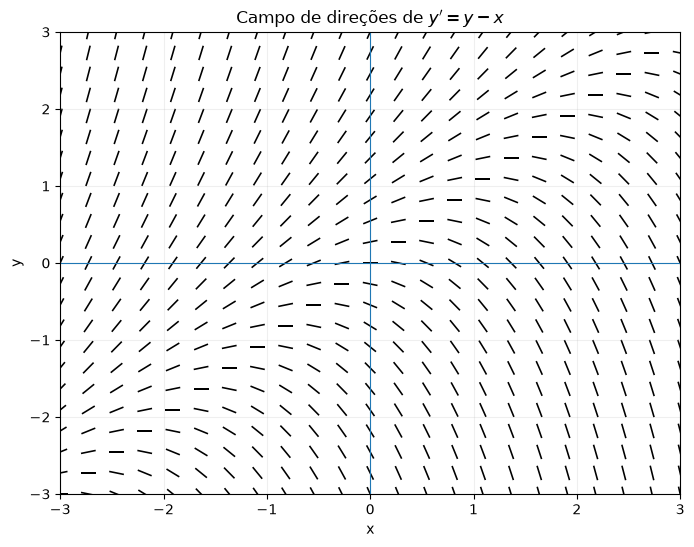

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def campo_direcoes(f, xlim=(-3,3), ylim=(-3,3), nx=23, ny=23):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)

    X, Y = np.meshgrid(xs, ys)
    M = f(X, Y)

    U = 1/np.sqrt(1 + M**2)
    V = M/np.sqrt(1 + M**2)

    plt.figure(figsize=(8,6))
    plt.quiver(
        X, Y, U, V,
        angles='xy',
        pivot='mid',
        headwidth=0,
        headlength=0,
        headaxislength=0
    )

    plt.axhline(0, linewidth=.8)
    plt.axvline(0, linewidth=.8)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(alpha=.2)

campo_direcoes(lambda x,y: y - x)
plt.title(r"Campo de direções de $y'=y-x$")
plt.show()

O campo fornece informação **local**: ele nos diz em que direção uma solução deve seguir ao passar por cada ponto.

Entretanto, em geral, o campo depende simultaneamente de $x$ e de $y$. Nas **equações autônomas** o lado direito da equação

não depende explicitamente do 'tempo' x. Falamos de um campo de vetores estacionário.


# 6.2 Equações autônomas

Uma equação de primeira ordem é chamada **autônoma** quando pode ser escrita na forma

$$
\boxed{
y'=f(y).
}
$$

A variável independente $x$ não aparece explicitamente no lado direito.

Por exemplo,

$$
y'=y(1-y)
$$

é autônoma.

Já

$$
y'=x(1-y)
$$

não é autônoma.

Nas equações autônomas, a inclinação depende apenas do valor de $y$.

Portanto, todos os pontos que possuem a mesma coordenada $y$ têm a mesma inclinação.

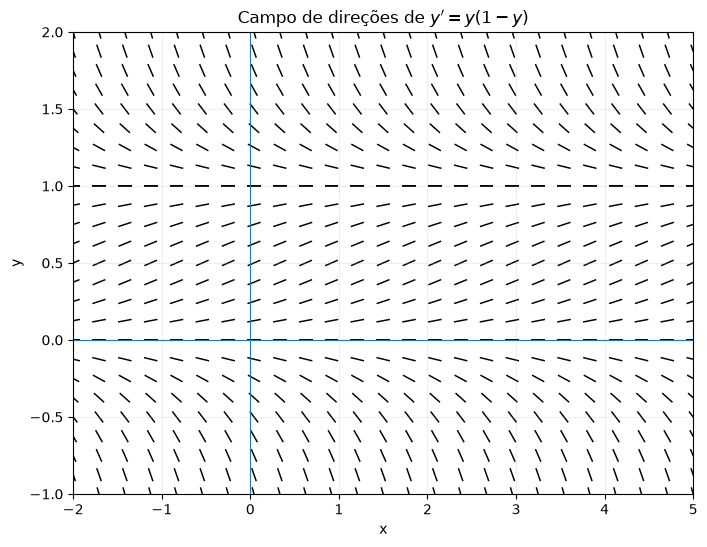

In [3]:
campo_direcoes(lambda x,y: y*(1-y),
               xlim=(-2,5), ylim=(-1,2),
               nx=25, ny=25)

plt.title(r"Campo de direções de $y'=y(1-y)$")
plt.show()

Observe as faixas horizontais no campo.

Em qualquer reta horizontal $y=c$,

$$
y'=f(c)
$$

é constante.

Essa estrutura especial permite reduzir grande parte da análise a um problema sobre a reta real.

## 6.3 Interpretação dinâmica

Em uma equação autônoma

$$
y'=f(y),
$$

podemos interpretar $y=y(x)$ como a posição de uma partícula que se move ao longo da reta real.

A derivada

$$
y'
$$

representa sua velocidade.

Assim:

- se $f(y)>0$, então $y'>0$ e a partícula se move para a **direita**;
- se $f(y)<0$, então $y'<0$ e a partícula se move para a **esquerda**;
- se $f(y)=0$, então a partícula permanece parada.

Isso nos leva naturalmente aos pontos de equilíbrio.

# 6.4 Pontos de equilíbrio

Um número $y^*$ é chamado de **ponto de equilíbrio** se

$$
\boxed{
f(y^*)=0.
}
$$

Nesse caso, a função constante

$$
\boxed{
y(x)=y^*
}
$$

é uma solução da EDO.

De fato,

$$
y'(x)=0
$$

e

$$
f(y(x))=f(y^*)=0.
$$

Essas soluções também são chamadas de **soluções de equilíbrio**, **soluções estacionárias** ou **soluções constantes**.

### Exemplo

Considere

$$
y'=y(1-y).
$$

Os equilíbrios satisfazem

$$
y(1-y)=0.
$$

Logo,

$$
\boxed{
y^*_1=0,
\qquad
y^*_2=1.
}
$$

Portanto,

$$
y(x)=0
$$

e

$$
y(x)=1
$$

são soluções constantes.

# 6.5 A linha de fase

Para estudar

$$
y'=f(y),
$$

marcamos os equilíbrios na reta real e analisamos o sinal de $f(y)$ nos intervalos entre eles.

Essa representação é chamada de **linha de fase**.

Para

$$
y'=y(1-y),
$$

temos:

- se $y<0$, então $f(y)<0$;
- se $0<y<1$, então $f(y)>0$;
- se $y>1$, então $f(y)<0$.

Portanto, a linha de fase é

$$
\leftarrow
\quad 0 \quad
\rightarrow
\quad 1 \quad
\leftarrow
$$

A direção das setas representa o sentido da evolução das soluções quando a variável independente aumenta.

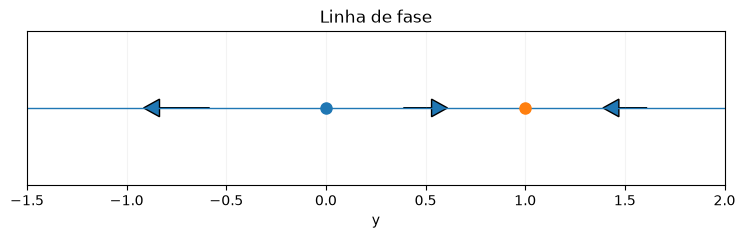

In [4]:
def linha_fase(f, equilibria, xmin, xmax, pontos_teste=None):
    plt.figure(figsize=(9,2))

    plt.axhline(0, linewidth=1)

    eq = sorted(equilibria)
    limites = [xmin] + eq + [xmax]

    if pontos_teste is None:
        pontos_teste = [(limites[i]+limites[i+1])/2
                        for i in range(len(limites)-1)]

    for a, b, p in zip(limites[:-1], limites[1:], pontos_teste):
        valor = f(p)
        centro = (a+b)/2
        largura = 0.22*(b-a)

        if valor > 0:
            plt.arrow(centro-largura/2, 0, largura, 0,
                      head_width=.08, head_length=.08,
                      length_includes_head=True)
        elif valor < 0:
            plt.arrow(centro+largura/2, 0, -largura, 0,
                      head_width=.08, head_length=.08,
                      length_includes_head=True)

    for e in eq:
        plt.plot(e, 0, 'o', markersize=8)

    plt.xlim(xmin, xmax)
    plt.ylim(-.35,.35)
    plt.yticks([])
    plt.xlabel("y")
    plt.title("Linha de fase")
    plt.grid(alpha=.15)
    plt.show()

f = lambda y: y*(1-y)

linha_fase(f, [0,1], -1.5, 2)

A linha de fase contém grande parte da informação qualitativa da EDO.

Sem resolver a equação, já sabemos para onde as soluções se movem dependendo da condição inicial.

# 6.6 Estabilidade

Considere um equilíbrio $y^*$.

Intuitivamente, dizemos que ele é **estável** quando soluções que começam suficientemente próximas permanecem próximas.

Para nossa análise qualitativa em dimensão um, há duas situações particularmente simples.

### Equilíbrio atrator

Se o fluxo aponta para o equilíbrio dos dois lados,

$$
\rightarrow\quad y^*\quad\leftarrow,
$$

então soluções próximas aproximam-se de $y^*$.

Chamaremos esse equilíbrio de **assintoticamente estável**.

### Equilíbrio repulsor

Se o fluxo aponta para fora,

$$
\leftarrow\quad y^*\quad\rightarrow,
$$

então pequenas perturbações afastam a solução do equilíbrio.

O equilíbrio é **instável**.

### Aplicação ao modelo logístico

Para

$$
y'=y(1-y),
$$

a linha de fase é

$$
\leftarrow
\quad 0 \quad
\rightarrow
\quad 1 \quad
\leftarrow.
$$

Assim,

$$
\boxed{y^*=0\text{ é instável}}
$$

e

$$
\boxed{y^*=1\text{ é assintoticamente estável}.}
$$

Se $0<y_0<1$, a solução cresce em direção a $1$.

Se $y_0>1$, a solução decresce em direção a $1$.

## 6.7 Estabilidade local e global

A classificação anterior é inicialmente **local**.

Um equilíbrio pode atrair todas as condições iniciais próximas, mas não necessariamente todas as condições iniciais possíveis.

Por isso distinguimos:

- **estabilidade local**: o comportamento é analisado para pequenas perturbações do equilíbrio;
- **estabilidade global**: o equilíbrio atrai todas as soluções admissíveis do domínio considerado.


Onservação : Um equilíbrio pode ser localmente estável sem ser globalmente estável.

# 6.8 Exemplo: $y'=y^2-1$

Considere

$$
y'=y^2-1.
$$

Os equilíbrios são encontrados resolvendo

$$
y^2-1=0.
$$

Logo,

$$
\boxed{
y^*=-1,\qquad y^*=1.
}
$$

Agora estudamos o sinal de

$$
f(y)=y^2-1.
$$

Temos

$$
f(y)>0
$$

para $y<-1$ e $y>1$, enquanto

$$
f(y)<0
$$

para

$$
-1<y<1.
$$

Portanto, a linha de fase é

$$
\rightarrow
\quad -1 \quad
\leftarrow
\quad 1 \quad
\rightarrow.
$$

Assim,

$$
\boxed{y=-1\text{ é estável}}
$$

e

$$
\boxed{y=1\text{ é instável}.}
$$

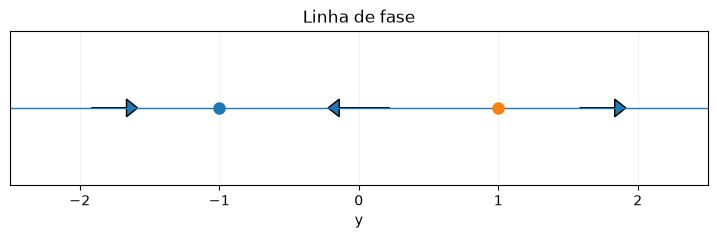

In [5]:
f = lambda y: y**2 - 1

linha_fase(f, [-1,1], -2.5, 2.5)

Esse exemplo ilustra um ponto importante: não precisamos conhecer explicitamente as soluções para classificar os equilíbrios.

O sinal de $f(y)$ é suficiente.

# 6.9 Um exemplo em que não conseguimos escrever o equilíbrio explicitamente

Considere

$$
y'=y-\cos y.
$$

Os equilíbrios satisfazem

$$
y-\cos y=0,
$$

isto é,

$$
y=\cos y.
$$

Essa equação não possui uma solução elementar explícita.

Entretanto, podemos estudar geometricamente os gráficos

$$
z=y
$$

e

$$
z=\cos y.
$$

O ponto de interseção determina o equilíbrio.

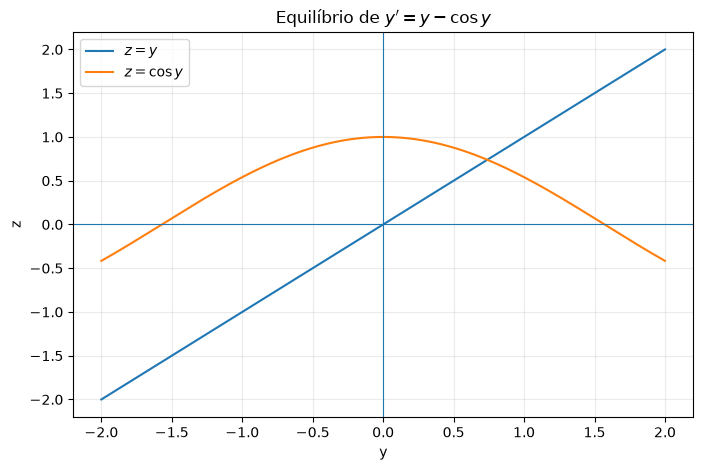

In [6]:
y = np.linspace(-2, 2, 500)

plt.figure(figsize=(8,5))
plt.plot(y, y, label=r"$z=y$")
plt.plot(y, np.cos(y), label=r"$z=\cos y$")
plt.axhline(0, linewidth=.8)
plt.axvline(0, linewidth=.8)
plt.xlabel("y")
plt.ylabel("z")
plt.title(r"Equilíbrio de $y'=y-\cos y$")
plt.grid(alpha=.25)
plt.legend()
plt.show()

Mesmo sem uma fórmula para $y^*$, podemos determinar sua estabilidade.

Se

$$
f(y)=y-\cos y,
$$

então à esquerda do ponto de interseção temos

$$
f(y)<0,
$$

e à direita,

$$
f(y)>0.
$$

Portanto, o fluxo se afasta do equilíbrio nos dois lados.

Assim, o único equilíbrio é **instável**.

Essa é uma das vantagens fundamentais da abordagem qualitativa: podemos classificar um equilíbrio mesmo sem conhecer sua expressão exata.

# 6.10 O modelo logístico

Considere agora

$$
N'
=
rN\left(1-\frac{N}{K}\right),
\qquad
r>0,\quad K>0.
$$

Os equilíbrios satisfazem

$$
rN\left(1-\frac{N}{K}\right)=0.
$$

Portanto,

$$
\boxed{
N^*=0,\qquad N^*=K.
}
$$

Como estamos interpretando $N$ como população, consideramos apenas

$$
N\geq0.
$$

Para

$$
0<N<K,
$$

temos

$$
N'>0.
$$

Para

$$
N>K,
$$

temos

$$
N'<0.
$$

Assim,

$$
N=0
$$

é instável e

$$
N=K
$$

é assintoticamente estável.

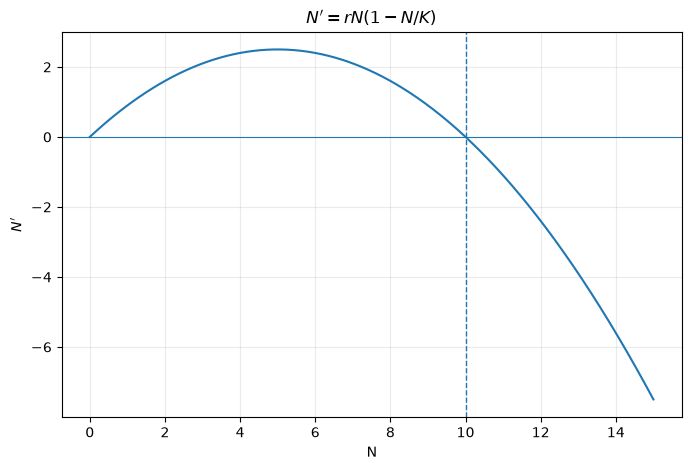

In [7]:
r = 1
K = 10

N = np.linspace(0, 15, 500)
fN = r*N*(1-N/K)

plt.figure(figsize=(8,5))
plt.plot(N, fN)
plt.axhline(0, linewidth=.8)
plt.axvline(K, linestyle="--", linewidth=1)
plt.xlabel("N")
plt.ylabel(r"$N'$")
plt.title(r"$N'=rN(1-N/K)$")
plt.grid(alpha=.25)
plt.show()

O gráfico de $f(N)$ fornece diretamente o sentido do fluxo:

- onde $f(N)>0$, a população aumenta;
- onde $f(N)<0$, a população diminui;
- onde $f(N)=0$, temos equilíbrio.

O máximo da parábola ocorre em

$$
N=\frac{K}{2}.
$$

Nesse ponto a taxa de crescimento $N'$ é máxima.

Isso permite inferir também a mudança de concavidade da curva $N(t)$ sem precisar resolver explicitamente a equação.

# 6.11 Análise linear de estabilidade

Até agora classificamos equilíbrios olhando para o sinal de $f(y)$.

Agora procuraremos um critério local mais quantitativo.

Considere

$$
y'=f(y)
$$

e seja $y^*$ um equilíbrio:

$$
f(y^*)=0.
$$

Introduzimos uma pequena perturbação

$$
\eta(x)=y(x)-y^*.
$$

Então

$$
y=y^*+\eta.
$$

Como $y^*$ é constante,

$$
\eta'=y'.
$$

Portanto,

$$
\eta'=f(y^*+\eta).
$$

## 6.12 Expansão de Taylor em torno do equilíbrio

Suponha que $f$ seja suficientemente regular.

Expandimos $f$ em torno de $y^*$:

$$
f(y^*+\eta)
=
f(y^*)
+
f'(y^*)\eta
+
O(\eta^2).
$$

Como

$$
f(y^*)=0,
$$

obtemos

$$
\eta'
=
f'(y^*)\eta
+
O(\eta^2).
$$

Para $|\eta|$ pequeno e

$$
f'(y^*)\neq0,
$$

os termos de ordem quadrática podem ser desprezados em primeira aproximação:

$$
\boxed{
\eta'
\approx
f'(y^*)\eta.
}
$$

Essa equação é chamada de **linearização da EDO em torno do equilíbrio**.

# 6.13 O critério de estabilidade

A equação linearizada é

$$
\eta'=\lambda\eta,
$$

onde

$$
\lambda=f'(y^*).
$$

Sua solução é

$$
\eta(x)=\eta_0e^{\lambda x}.
$$

Portanto:

### Se $f'(y^*)<0$

Então

$$
e^{f'(y^*)x}\longrightarrow0
\qquad
\text{quando }x\to+\infty.
$$

A perturbação decai.

Logo,

$$
\boxed{
f'(y^*)<0
\quad\Longrightarrow\quad
y^*\text{ é assintoticamente estável}.
}
$$

### Se $f'(y^*)>0$

A perturbação cresce exponencialmente.

Logo,

$$
\boxed{
f'(y^*)>0
\quad\Longrightarrow\quad
y^*\text{ é instável}.
}
$$

## 6.14 Interpretação geométrica do critério

O critério pode ser compreendido diretamente pelo gráfico de $f$.

Se

$$
f'(y^*)<0,
$$

o gráfico de $f$ cruza o eixo horizontal com inclinação negativa.

Assim, perto de $y^*$,

- à esquerda, $f(y)>0$;
- à direita, $f(y)<0$.

Logo,

$$
\rightarrow
\quad y^*
\quad
\leftarrow,
$$

e o equilíbrio é atrator.

Se

$$
f'(y^*)>0,
$$

o sentido é inverso:

$$
\leftarrow
\quad y^*
\quad
\rightarrow.
$$

O equilíbrio é repulsor.

Portanto, a análise linear formaliza exatamente o que já enxergávamos na linha de fase.

# 6.15 Aplicação a $y'=\sin y$

Considere

$$
y'=\sin y.
$$

Os equilíbrios são

$$
\boxed{
y^*=k\pi,
\qquad
k\in\mathbb Z.
}
$$

Como

$$
f'(y)=\cos y,
$$

temos

$$
f'(k\pi)=\cos(k\pi)=(-1)^k.
$$

Portanto:

- se $k$ é par, $f'(k\pi)=1>0$: equilíbrio instável;
- se $k$ é ímpar, $f'(k\pi)=-1<0$: equilíbrio estável.

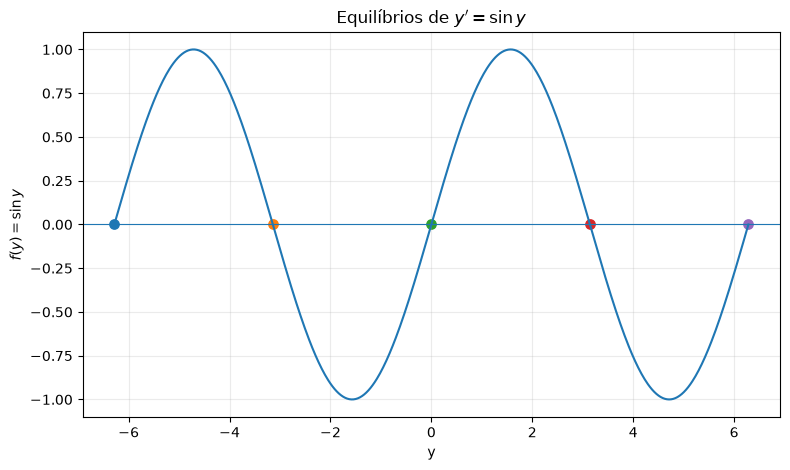

In [8]:
y = np.linspace(-2*np.pi, 2*np.pi, 600)

plt.figure(figsize=(9,5))
plt.plot(y, np.sin(y))
plt.axhline(0, linewidth=.8)

for k in range(-2,3):
    plt.scatter([k*np.pi], [0], s=45)

plt.xlabel("y")
plt.ylabel(r"$f(y)=\sin y$")
plt.title(r"Equilíbrios de $y'=\sin y$")
plt.grid(alpha=.25)
plt.show()

A alternância entre equilíbrios estáveis e instáveis pode ser vista diretamente no gráfico.

# 6.16 Aplicação ao modelo logístico

Para

$$
f(N)=rN\left(1-\frac{N}{K}\right),
$$

temos

$$
f'(N)
=
r-\frac{2r}{K}N.
$$

No equilíbrio $N^*=0$,

$$
f'(0)=r>0.
$$

Logo,

$$
\boxed{N=0\text{ é instável}.}
$$

No equilíbrio $N^*=K$,

$$
f'(K)
=
r-2r
=
-r<0.
$$

Logo,

$$
\boxed{N=K\text{ é assintoticamente estável}.}
$$

A análise linear confirma exatamente o resultado obtido pela linha de fase.

# 6.17 Escala de tempo característica

A linearização

$$
\eta'=f'(y^*)\eta
$$

tem solução

$$
\eta(x)=\eta_0e^{f'(y^*)x}.
$$

A quantidade

$$
|f'(y^*)|
$$

mede a taxa exponencial local de crescimento ou decaimento das perturbações.

Assim, uma escala de tempo natural é

$$
\boxed{
\tau=
\frac{1}{|f'(y^*)|}.
}
$$

Quanto maior $|f'(y^*)|$, mais rapidamente as soluções se afastam ou se aproximam do equilíbrio.

Para o equilíbrio estável $N=K$ do modelo logístico,

$$
f'(K)=-r,
$$

portanto

$$
\boxed{
\tau=\frac1r.
}
$$

# 6.18 O caso $f'(y^*)=0$

O critério anterior exige

$$
f'(y^*)\neq0.
$$

Quando

$$
f'(y^*)=0,
$$

a linearização fornece apenas

$$
\eta'\approx0
$$

e não contém informação suficiente para decidir a estabilidade.

Nesse caso precisamos examinar os termos não lineares ou retornar à linha de fase.

### Exemplo 1

Considere

$$
y'=-y^3.
$$

O único equilíbrio é

$$
y^*=0.
$$

Temos

$$
f'(0)=0.
$$

Entretanto:

- se $y>0$, então $y'<0$;
- se $y<0$, então $y'>0$.

Logo,

$$
\rightarrow
\quad 0
\quad
\leftarrow.
$$

Portanto,

$$
\boxed{y=0\text{ é assintoticamente estável}.}
$$

### Exemplo 2

Considere

$$
y'=y^3.
$$

Novamente,

$$
f'(0)=0.
$$

Mas agora:

- se $y>0$, então $y'>0$;
- se $y<0$, então $y'<0$.

Logo,

$$
\leftarrow
\quad 0
\quad
\rightarrow.
$$

Portanto,

$$
\boxed{y=0\text{ é instável}.}
$$

Assim,

$$
f'(y^*)=0
$$

não implica estabilidade nem instabilidade.

# 6.19 Equilíbrio semiestável

Considere

$$
y'=y^2.
$$

O único equilíbrio é

$$
y^*=0.
$$

Temos

$$
f'(0)=0.
$$

Além disso,

$$
y^2>0
$$

para todo $y\neq0$.

Portanto, o fluxo aponta para a direita dos dois lados:

$$
\rightarrow
\quad 0
\quad
\rightarrow.
$$

Uma solução que começa com $y_0<0$ aproxima-se de $0$ pela esquerda, enquanto uma solução com $y_0>0$ afasta-se de $0$.

Esse tipo de equilíbrio é chamado de **semiestável**.

In [ ]:
ys = np.linspace(-1.5, 1.5, 500)

plt.figure(figsize=(8,5))
plt.plot(ys, -ys**3, label=r"$-y^3$")
plt.plot(ys, ys**3, label=r"$y^3$")
plt.plot(ys, ys**2, label=r"$y^2$")
plt.axhline(0, linewidth=.8)
plt.axvline(0, linewidth=.8)
plt.xlabel("y")
plt.ylabel("f(y)")
plt.title(r"Casos com $f'(0)=0$")
plt.grid(alpha=.25)
plt.legend()
plt.show()

O gráfico mostra por que o valor

$$
f'(0)=0
$$

não decide sozinho a estabilidade.

É necessário observar o comportamento de $f(y)$ em torno do equilíbrio.

# 6.20 Campo de direções e linha de fase são duas visões do mesmo problema

Para uma equação autônoma

$$
y'=f(y),
$$

o campo de direções no plano $(x,y)$ repete horizontalmente a mesma informação.

A linha de fase comprime essa informação em uma única reta.

Por exemplo, para

$$
y'=y(1-y),
$$

o campo de direções mostra faixas horizontais, enquanto a linha de fase registra apenas:

$$
\leftarrow
\quad 0 \quad
\rightarrow
\quad 1
\quad \leftarrow.
$$

Assim, para equações autônomas em uma dimensão, a linha de fase é frequentemente a ferramenta mais eficiente.

In [ ]:
campo_direcoes(lambda x,y: y*(1-y),
               xlim=(-2,5), ylim=(-1,2),
               nx=25, ny=25)

x = np.linspace(-2,5,400)
plt.plot(x, np.zeros_like(x), linewidth=2, label=r"$y=0$")
plt.plot(x, np.ones_like(x), linewidth=2, label=r"$y=1$")
plt.title(r"Campo de direções e equilíbrios de $y'=y(1-y)$")
plt.legend()
plt.show()

# 6.21 Um roteiro para a análise de uma EDO autônoma

Dada

$$
y'=f(y),
$$

podemos proceder da seguinte maneira.

### 1. Encontre os equilíbrios

Resolva

$$
f(y^*)=0.
$$

### 2. Divida a reta em intervalos

Os equilíbrios separam a reta em regiões.

### 3. Determine o sinal de $f$

Em cada intervalo, verifique se

$$
f(y)>0
$$

ou

$$
f(y)<0.
$$

### 4. Construa a linha de fase

Use

$$
f(y)>0
\quad\Rightarrow\quad
\rightarrow
$$

e

$$
f(y)<0
\quad\Rightarrow\quad
\leftarrow.
$$

### 5. Classifique os equilíbrios

- fluxo entrando dos dois lados: assintoticamente estável;
- fluxo saindo dos dois lados: instável;
- fluxo entrando de um lado e saindo do outro: semiestável.

### 6. Quando possível, use a análise linear

Calcule

$$
f'(y^*).
$$

Se

$$
f'(y^*)<0,
$$

o equilíbrio é assintoticamente estável.

Se

$$
f'(y^*)>0,
$$

é instável.

Se

$$
f'(y^*)=0,
$$

retorne à análise não linear.

# Exercícios

### Exercício 1

Para

$$
y'=y^2-4,
$$

1. determine os equilíbrios;
2. construa a linha de fase;
3. classifique cada equilíbrio;
4. confirme sua classificação usando $f'(y^*)$.

---

### Exercício 2

Considere

$$
y'=y(2-y).
$$

1. encontre os equilíbrios;
2. determine as regiões onde as soluções crescem e decrescem;
3. classifique os equilíbrios;
4. construa o campo de direções.

---

### Exercício 3

Considere

$$
y'=\sin y.
$$

Determine e classifique todos os equilíbrios.

Mostre que os equilíbrios estáveis e instáveis se alternam.

---

### Exercício 4

Considere

$$
y'=y-\cos y.
$$

1. mostre graficamente que existe um único equilíbrio;
2. classifique-o sem calcular explicitamente sua posição;
3. confirme sua classificação usando $f'(y)$.

---

### Exercício 5

Para

$$
y'=-y^3,
$$

mostre que $y=0$ é assintoticamente estável embora

$$
f'(0)=0.
$$

Explique por que a análise linear não é suficiente nesse caso.

---

### Exercício 6

Para

$$
y'=y^2,
$$

mostre que $y=0$ é semiestável.

Descreva separadamente o comportamento para $y_0<0$ e $y_0>0$.

---

### Exercício 7

Considere

$$
y'=y(1-y)(y-2).
$$

1. determine todos os equilíbrios;
2. construa a linha de fase;
3. classifique-os;
4. determine o limite de $y(x)$ quando $x\to+\infty$ para diferentes condições iniciais.

---

### Exercício 8 — estabilidade linear

Seja

$$
y'=f(y)
$$

e suponha que $f(y^*)=0$ e $f'(y^*)\neq0$.

Usando

$$
y=y^*+\eta,
$$

derive a equação linearizada

$$
\eta'=f'(y^*)\eta
$$

e explique por que o sinal de $f'(y^*)$ determina a estabilidade local.

---

### Exercício 9 — modelo logístico

Considere

$$
N'=rN\left(1-\frac{N}{K}\right),
\qquad r,K>0.
$$

1. encontre e classifique os equilíbrios;
2. determine a escala de tempo característica em torno de cada equilíbrio;
3. determine onde $N(t)$ é crescente ou decrescente;
4. determine qualitativamente o comportamento para $N_0>K$.

---

### Exercício 10 — exploração computacional

Escolha uma das equações

$$
y'=y^2-1,
$$

$$
y'=y(1-y)(y-2),
$$

ou

$$
y'=\sin y.
$$

Construa:

1. o gráfico de $f(y)$;
2. a linha de fase;
3. o campo de direções;
4. uma identificação visual dos equilíbrios;
5. a classificação de estabilidade.

Compare a informação fornecida pelas três representações.

## Para pensar

Uma equação autônoma

$$
y'=f(y)
$$

pode ser extremamente difícil de resolver explicitamente e, ainda assim, possuir uma dinâmica muito simples de compreender.

A informação essencial está frequentemente no sinal de $f$.

Os zeros de $f$ determinam os equilíbrios.

O sinal de $f$ determina o fluxo.

A derivada $f'(y^*)$ descreve o comportamento local em torno de um equilíbrio hiperbólico.

Assim, passamos de uma pergunta essencialmente analítica,

> **Qual é a fórmula para $y(x)$?**

para uma pergunta dinâmica,

> **Como as soluções se comportam?**

Essa mudança de perspectiva será fundamental quando passarmos a estudar sistemas em dimensões maiores.